# Grammar Scoring Engine for Spoken Audio

**Task:** predict a continuous MOS-Likert grammar score (0-5) from a 45-60 s speech clip.
**Data:** 769 training clips, 216 test clips. **Metrics:** Pearson correlation and RMSE.

## Report (summary of approach)

**Key idea.** Grammar is a property of *what was said*, so the audio is first converted to text, and grammar quality is
then estimated from the transcript. Acoustic information (fluency, hesitation, confidence) is a useful complementary signal.

**Pipeline**
1. **Preprocessing:** resample to 16 kHz mono; locate audio files by name; clip labels to [0, 5].
2. **ASR:** `faster-whisper` produces a transcript with word-level timestamps and word confidence. The prompt contains
   fillers ("um", "uh") so disfluencies are kept rather than silently cleaned.
3. **Feature groups**
   * *Handcrafted fluency/grammar features:* speech rate, pause statistics, filler and repetition counts, sentence-length
     statistics, lexical diversity, clause-connector usage, ASR confidence statistics.
   * *Grammar-checker features:* LanguageTool error counts per 100 words (total and grammar-specific), if Java is available.
   * *Language-model fluency:* DistilGPT-2 perplexity statistics (ungrammatical text has higher perplexity).
   * *Text embeddings:* sentence-transformer embedding of the transcript.
   * *Audio embeddings:* mean-pooled wav2vec2 hidden states.
4. **Models:** gradient boosting / ExtraTrees / LightGBM on handcrafted features, ridge on each of two text encoders + handcrafted
   features, SVR on PCA-reduced embeddings from two audio encoders (wav2vec2, WavLM). Out-of-fold predictions from repeated
   stratified CV are combined by a non-negative linear stacker or a simple mean (whichever is better in nested CV); outputs are clipped to [0, 5].
5. **Evaluation:** 5-fold stratified cross-validation (out-of-fold RMSE, Pearson, Spearman) **plus the compulsory training-set RMSE**
   (final model refit on all training data and evaluated on the training data). Training RMSE is optimistic; the out-of-fold
   numbers are the honest estimate of test performance.

The result tables and plots below are produced when the notebook is run; the final cell prints a results summary.

## 1. Setup

**Kaggle notes.** Add the competition data (`Dataset_Final`: `train/`, `test/`, `train.csv`, `test.csv`, `sample_submission.csv`) and use a GPU
session (T4/P100). The pretrained models are downloaded from the Hugging Face hub, so turn **Internet on** (or attach them as Kaggle Models).
No external *data* is used, in line with the competition rules. Outputs (`submission.csv`, `submission_mean.csv`) are written to `/kaggle/working`.

In [ ]:
!pip install -q faster-whisper librosa soundfile sentence-transformers transformers torch scikit-learn seaborn tqdm
!pip install -q language_tool_python        

In [ ]:
import os, re, json, random, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import torch
from tqdm.auto import tqdm

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import RidgeCV, LinearRegression
from sklearn.svm import SVR
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_squared_error
from scipy.stats import pearsonr, spearmanr

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

# edit DATA_DIR to point at the competition folder 
ON_KAGGLE = Path("/kaggle/input").exists()
DATA_DIR = Path("/kaggle/input") if ON_KAGGLE else Path(".")  
OUT_DIR = Path("/kaggle/working") if ON_KAGGLE else Path(".")
CACHE = OUT_DIR / "cache"; (CACHE / "asr").mkdir(parents=True, exist_ok=True)
SR = 16000                     
WHISPER_SIZE = "medium"        
USE_AUDIO_EMB = True            # wav2vec2 / WavLM embeddings
AUDIO_BACKBONES = ["facebook/wav2vec2-base-960h", "microsoft/wavlm-base-plus"] if USE_AUDIO_EMB else []
TEXT_ENCODERS = ["sentence-transformers/all-mpnet-base-v2", "BAAI/bge-large-en-v1.5"]
USE_LANGUAGETOOL = True         
N_FOLDS = 5
N_REPEATS = 3                   
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", DEVICE)

## 2. Load data and exploratory analysis

In [ ]:
def find_csv(name):
    hits = list(DATA_DIR.rglob(name))
    assert hits, f"{name} not found under {DATA_DIR.resolve()}"
    return hits[0]

train = pd.read_csv(find_csv("train.csv"))
test = pd.read_csv(find_csv("test.csv"))
sample_sub = pd.read_csv(find_csv("sample_submission.csv"))

FILE_COL = train.columns[0]
LABEL_COL = [c for c in train.columns if c != FILE_COL][0]
print("file column:", FILE_COL, "| label column:", LABEL_COL)
print(train.shape, test.shape, sample_sub.shape)


def _wav(name):
    name = str(name)
    return name if name.lower().endswith(".wav") else name + ".wav"

audio_index, flat_index = {}, {}
for p in DATA_DIR.rglob("*.wav"):
    parts = [q.lower() for q in p.parent.parts]
    for split in ("train", "test"):
        if split in parts:
            audio_index[(split, p.name)] = p
    flat_index.setdefault(p.name, p)           

train["uid"] = "train/" + train[FILE_COL].astype(str)
test["uid"] = "test/" + test[FILE_COL].astype(str)

def resolve(uid):
    split, name = uid.split("/", 1)
    name = _wav(name)
    return audio_index.get((split, name)) or flat_index[name]

missing = [u for u in list(train["uid"]) + list(test["uid"])
           if (u.split("/", 1)[0], _wav(u.split("/", 1)[1])) not in audio_index and _wav(u.split("/", 1)[1]) not in flat_index]
print("wav files found:", sum(1 for _ in audio_index), "| csv rows without audio:", len(missing))
assert not missing, f"audio not found for e.g. {missing[:3]}"

train[LABEL_COL] = train[LABEL_COL].astype(float).clip(0, 5)
train.head()

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.countplot(x=train[LABEL_COL].round(1), ax=ax[0], color="steelblue")
ax[0].set_title("Training label distribution"); ax[0].set_xlabel("Grammar score")
durs = [librosa.get_duration(path=str(resolve(f))) for f in tqdm(train["uid"][:200])]
sns.histplot(durs, bins=20, ax=ax[1], color="darkorange")
ax[1].set_title("Clip durations (first 200 train files)"); ax[1].set_xlabel("seconds")
plt.tight_layout(); plt.show()
print(train[LABEL_COL].describe())

## 3. Speech-to-text (Whisper) with word timestamps
Transcripts are cached to disk, so the slow step runs once.

In [ ]:
from faster_whisper import WhisperModel

asr = WhisperModel(WHISPER_SIZE, device=DEVICE,
                   compute_type="float16" if DEVICE == "cuda" else "int8")
# prompt that encourages Whisper to keep fillers / false starts (they carry fluency information)
PROMPT = "Umm, let me think, like, hmm... Okay, so, uh, I think it's, you know, basically this."

def transcribe(fname):
    cp = CACHE / "asr" / (fname.replace("/", "__") + ".json")
    if cp.exists():
        return json.load(open(cp))
   
    wav, _ = librosa.load(str(resolve(fname)), sr=SR, mono=True)
    segs, _ = asr.transcribe(wav.astype("float32"), language="en", beam_size=5,
                             word_timestamps=True, condition_on_previous_text=False,
                             initial_prompt=PROMPT)
    words, text = [], []
    for s in segs:
        text.append(s.text.strip())
        for w in (s.words or []):
            words.append(dict(w=w.word.strip(), s=float(w.start), e=float(w.end), p=float(w.probability)))
    out = dict(text=" ".join(text), words=words)
    json.dump(out, open(cp, "w"))
    return out

all_files = pd.concat([train["uid"], test["uid"]]).tolist()
asr_out = {f: transcribe(f) for f in tqdm(all_files, desc="transcribing")}
for f in train["uid"][:3]:
    print(f, "->", asr_out[f]["text"][:300], "\n")

## 4. Feature engineering

### 4.1 Handcrafted fluency / grammar-proxy features

In [ ]:
FILLERS = {"um", "uh", "er", "erm", "ah", "hmm", "mm", "umm", "uhm", "eh"}
CONNECTORS = {"because", "although", "though", "which", "while", "whereas", "however", "if", "when",
              "that", "since", "unless", "therefore", "but", "so", "and"}
AUX = {"is", "are", "was", "were", "am", "be", "been", "has", "have", "had", "do", "does", "did",
       "will", "would", "can", "could", "should", "may", "might"}

def hand_features(out, dur):
    words, text = out["words"], out["text"]
    toks = [re.sub(r"[^a-z']", "", w["w"].lower()) for w in words]
    toks = [t for t in toks if t]
    n = max(len(toks), 1)
    probs = np.array([w["p"] for w in words]) if words else np.array([0.0])
    gaps = (np.array([words[i + 1]["s"] - words[i]["e"] for i in range(len(words) - 1)])
            if len(words) > 1 else np.array([0.0]))
    gaps = np.clip(gaps, 0, None)
    span = (words[-1]["e"] - words[0]["s"]) if len(words) > 1 else dur
    sents = [s.strip() for s in re.split(r"[.!?]+", text) if s.strip()]
    sl = np.array([len(s.split()) for s in sents]) if sents else np.array([0])
    reps = sum(1 for i in range(1, len(toks)) if toks[i] == toks[i - 1])
    bigrams = list(zip(toks, toks[1:]))
    return dict(
        n_words=len(toks), duration=dur, wpm=len(toks) / max(dur, 1) * 60,
        articulation_rate=len(toks) / max(span, 1) * 60,
        speech_ratio=span / max(dur, 1),
        mean_prob=probs.mean(), min_prob=probs.min(), std_prob=probs.std(),
        low_conf_frac=(probs < 0.5).mean(), vlow_conf_frac=(probs < 0.2).mean(),
        n_pauses_05=(gaps > 0.5).sum(), n_pauses_10=(gaps > 1.0).sum(),
        pause_rate=(gaps > 0.5).sum() / max(dur, 1) * 60,
        mean_gap=gaps.mean(), max_gap=gaps.max(), std_gap=gaps.std(),
        n_sents=len(sents), mean_sent_len=sl.mean(), std_sent_len=sl.std(), max_sent_len=sl.max(),
        short_sent_frac=(sl < 4).mean(),
        ttr=len(set(toks)) / n, mean_word_len=np.mean([len(t) for t in toks]) if toks else 0,
        long_word_frac=np.mean([len(t) >= 7 for t in toks]) if toks else 0,
        filler_rate=sum(t in FILLERS for t in toks) / n * 100,
        repeat_rate=reps / n * 100,
        bigram_repeat_rate=(len(bigrams) - len(set(bigrams))) / max(len(bigrams), 1) * 100,
        connector_rate=sum(t in CONNECTORS for t in toks) / n * 100,
        aux_rate=sum(t in AUX for t in toks) / n * 100,
        ed_rate=sum(t.endswith("ed") for t in toks) / n * 100,
        i_rate=sum(t in {"i", "i'm", "i've", "i'll"} for t in toks) / n * 100,
    )

def duration(f):
    return librosa.get_duration(path=str(resolve(f)))

durations = {f: duration(f) for f in tqdm(all_files, desc="durations")}
hand = pd.DataFrame({f: hand_features(asr_out[f], durations[f]) for f in all_files}).T
print(hand.shape)
hand.head()

### 4.2 Grammar-checker (LanguageTool) and language-model perplexity features

In [ ]:
lt = None
if USE_LANGUAGETOOL:
    try:
        import language_tool_python
        lt = language_tool_python.LanguageTool("en-US")
        print("LanguageTool ready")
    except Exception as e:
        print("LanguageTool unavailable, skipping:", repr(e)[:120])

def lt_features(text):
    n = max(len(text.split()), 1)
    if lt is None or not text.strip():
        return dict(lt_total=0.0, lt_grammar=0.0, lt_spell=0.0, lt_other=0.0)
    ms = lt.check(text)
    cat = lambda m: str(getattr(m, "category", "")).upper()
    gram = sum(c in ("GRAMMAR", "CONFUSED_WORDS", "PUNCTUATION") or "GRAMMAR" in c for c in map(cat, ms))
    spell = sum("TYPO" in c or "SPELL" in c for c in map(cat, ms))
    return dict(lt_total=len(ms) / n * 100, lt_grammar=gram / n * 100,
                lt_spell=spell / n * 100, lt_other=(len(ms) - gram - spell) / n * 100)

lt_df = pd.DataFrame({f: lt_features(asr_out[f]["text"]) for f in tqdm(all_files, desc="languagetool")}).T


from transformers import AutoTokenizer, AutoModelForCausalLM
tok_lm = AutoTokenizer.from_pretrained("distilgpt2")
lm = AutoModelForCausalLM.from_pretrained("distilgpt2").to(DEVICE).eval()

@torch.no_grad()
def ppl_features(text):
    ids = tok_lm(text, return_tensors="pt", truncation=True, max_length=1024).input_ids.to(DEVICE)
    if ids.shape[1] < 3:
        return dict(ppl_mean=0.0, ppl_median=0.0, ppl_p90=0.0, ppl_std=0.0)
    logits = lm(ids).logits[0, :-1]
    nll = torch.nn.functional.cross_entropy(logits, ids[0, 1:], reduction="none").cpu().numpy()
    return dict(ppl_mean=float(nll.mean()), ppl_median=float(np.median(nll)),
                ppl_p90=float(np.percentile(nll, 90)), ppl_std=float(nll.std()))

ppl_df = pd.DataFrame({f: ppl_features(asr_out[f]["text"]) for f in tqdm(all_files, desc="perplexity")}).T

### 4.3 Text and audio embeddings

In [ ]:
from sentence_transformers import SentenceTransformer
texts = [asr_out[f]["text"] for f in all_files]
text_embs = {}
for nm in TEXT_ENCODERS:
    enc = SentenceTransformer(nm, device=DEVICE)
    e = enc.encode(texts, batch_size=32, show_progress_bar=True, normalize_embeddings=True)
    text_embs[nm] = pd.DataFrame(e, index=all_files)
    print(nm, text_embs[nm].shape)
    del enc; torch.cuda.empty_cache()

In [ ]:
import pickle
from transformers import AutoFeatureExtractor, AutoModel
audio_embs = {}
for bb in AUDIO_BACKBONES:
    cp = CACHE / ("aud_" + bb.split("/")[-1] + ".pkl")
    if cp.exists():
        audio_embs[bb] = pickle.load(open(cp, "rb")); continue
    fe = AutoFeatureExtractor.from_pretrained(bb)
    net = AutoModel.from_pretrained(bb).to(DEVICE).eval()

    @torch.no_grad()
    def embed(f, fe=fe, net=net):
        wav, _ = librosa.load(str(resolve(f)), sr=SR, mono=True)
        wav = wav[: SR * 60]
        inp = fe(wav, sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE)
        h = net(inp, output_hidden_states=True).hidden_states
        # mean + std pooling of a middle layer and the last layer
        return torch.cat([torch.cat([h[i][0].mean(0), h[i][0].std(0)]) for i in (6, 12)]).cpu().numpy()

    audio_embs[bb] = pd.DataFrame({f: embed(f) for f in tqdm(all_files, desc=bb)}).T
    pickle.dump(audio_embs[bb], open(cp, "wb"))
    del net; torch.cuda.empty_cache()
    print(bb, audio_embs[bb].shape)

## 5. Assemble feature matrices and inspect them

In [ ]:
tab = pd.concat([hand, lt_df, ppl_df], axis=1).astype(float).fillna(0.0)
tr_files, te_files = train["uid"].tolist(), test["uid"].tolist()
y = train[LABEL_COL].values
X_tab, X_tab_te = tab.loc[tr_files].values, tab.loc[te_files].values
short = lambda nm: nm.split("/")[-1]
print("handcrafted feature matrix:", X_tab.shape)

corr = tab.loc[tr_files].assign(y=y).corr(method="spearman")["y"].drop("y").sort_values()
top = pd.concat([corr.head(10), corr.tail(10)])
plt.figure(figsize=(7, 7))
top.plot.barh(color=np.where(top > 0, "seagreen", "indianred"))
plt.title("Spearman correlation of handcrafted features with grammar score"); plt.tight_layout(); plt.show()

## 6. Modelling and cross-validation
Each base learner sees a different view of the data (handcrafted features, two text encoders, two audio encoders).
Out-of-fold (OOF) predictions are produced with **repeated stratified 5-fold CV** and then combined either by a
non-negative linear stacker or a simple mean, whichever has the lower nested-CV RMSE.

In [ ]:
from sklearn.ensemble import ExtraTreesRegressor
try:
    import lightgbm as lgb
    HAS_LGB = True
except Exception:
    HAS_LGB = False

def make_strata(y, k):
    # stratify on the rounded label; merge classes too small to split into k folds
    s = pd.Series(np.round(y).astype(int))
    vc = s.value_counts()
    for cls in vc[vc < k].index:
        s[s == cls] = vc[vc >= k].index[np.argmin(np.abs(vc[vc >= k].index.values - cls))]
    return s.values

strata = make_strata(y, N_FOLDS)
fold_sets = [list(StratifiedKFold(N_FOLDS, shuffle=True, random_state=SEED + r).split(y, strata)) for r in range(N_REPEATS)]

def rmse(a, b): return float(np.sqrt(mean_squared_error(a, b)))
def report(name, yt, yp):
    yp = np.clip(yp, 0, 5)
    return dict(model=name, RMSE=rmse(yt, yp), Pearson=pearsonr(yt, yp)[0], Spearman=spearmanr(yt, yp)[0])

#  base learners 
def m_gbm():
    return HistGradientBoostingRegressor(max_depth=3, learning_rate=0.04, max_iter=400,
                                         l2_regularization=1.0, min_samples_leaf=10, random_state=SEED)
def m_et():
    return ExtraTreesRegressor(n_estimators=600, min_samples_leaf=3, max_features=0.5, n_jobs=-1, random_state=SEED)
def m_lgbm():
    return lgb.LGBMRegressor(n_estimators=500, learning_rate=0.03, num_leaves=8, subsample=0.8, subsample_freq=1,
                             colsample_bytree=0.7, reg_lambda=2.0, min_child_samples=10, random_state=SEED, verbose=-1)
def m_ridge():
    return make_pipeline(StandardScaler(), RidgeCV(alphas=np.logspace(0, 4, 20)))
def m_svr():
    return make_pipeline(StandardScaler(), PCA(64, random_state=SEED), SVR(C=2.0, epsilon=0.1, gamma="scale"))

# model factory, train matrix, test matrix
views = {"GBM (handcrafted)": (m_gbm, X_tab, X_tab_te),
         "ExtraTrees (handcrafted)": (m_et, X_tab, X_tab_te)}
if HAS_LGB:
    views["LightGBM (handcrafted)"] = (m_lgbm, X_tab, X_tab_te)
for nm, emb in text_embs.items():
    views[f"Ridge (text: {short(nm)} + handcrafted)"] = (
        m_ridge, np.hstack([emb.loc[tr_files].values, X_tab]), np.hstack([emb.loc[te_files].values, X_tab_te]))
for nm, emb in audio_embs.items():
    views[f"SVR (audio: {short(nm)})"] = (
        m_svr, emb.loc[tr_files].values.astype(float), emb.loc[te_files].values.astype(float))
print(len(views), "base models:", list(views))

oof, oof_single = {}, {}
for name, (mk, Xtr, _) in views.items():
    reps = []
    for folds in fold_sets:
        p = np.zeros(len(y))
        for tr_i, va_i in folds:
            p[va_i] = mk().fit(Xtr[tr_i], y[tr_i]).predict(Xtr[va_i])
        reps.append(p)
    oof[name] = np.mean(reps, axis=0)
    oof_single[name] = np.mean([rmse(y, np.clip(p, 0, 5)) for p in reps])
    print(f"{name:52s} OOF RMSE (avg of repeats) = {oof_single[name]:.4f}")

In [ ]:
O = np.column_stack(list(oof.values()))
stack_oof = np.zeros(len(y))
for tr_i, va_i in fold_sets[0]:
    stack_oof[va_i] = LinearRegression(positive=True).fit(O[tr_i], y[tr_i]).predict(O[va_i])
mean_oof = O.mean(axis=1)

stacker = LinearRegression(positive=True).fit(O, y)
USE_STACK = rmse(y, np.clip(stack_oof, 0, 5)) <= rmse(y, np.clip(mean_oof, 0, 5))
print("blend weights:", dict(zip(oof.keys(), stacker.coef_.round(3))), "| intercept:", round(stacker.intercept_, 3))
print("chosen combiner:", "non-negative stacker" if USE_STACK else "simple mean")

cv_table = pd.DataFrame([{"model": n, "RMSE": oof_single[n], **{k: v for k, v in report(n, y, p).items() if k not in ("model", "RMSE")}}
                         for n, p in oof.items()]
                        + [report("Stacked blend (nested CV)", y, stack_oof), report("Simple mean blend", y, mean_oof)]).set_index("model")
cv_table.round(4)

## 7. Final fit, compulsory training RMSE, and evaluation plots

In [ ]:
final_models, train_preds, test_preds = {}, {}, {}
for name, (mk, Xtr, Xte) in views.items():
    m = mk().fit(Xtr, y)
    final_models[name] = m
    train_preds[name] = m.predict(Xtr)
    test_preds[name] = m.predict(Xte)

P_train = np.column_stack([train_preds[n] for n in views])
P_test = np.column_stack([test_preds[n] for n in views])

combine = (lambda P: stacker.predict(P)) if USE_STACK else (lambda P: P.mean(axis=1))
y_train_pred = np.clip(combine(P_train), 0, 5)             
y_test_pred = np.clip(combine(P_test), 0, 5)
y_test_mean = np.clip(P_test.mean(axis=1), 0, 5)           
y_oof_pred = np.clip(stack_oof if USE_STACK else mean_oof, 0, 5)

TRAIN_RMSE = rmse(y, y_train_pred)
OOF_RMSE = rmse(y, y_oof_pred)
OOF_PEARSON = pearsonr(y, y_oof_pred)[0]
print("=" * 62)
print(f"TRAINING RMSE (final model on training data) : {TRAIN_RMSE:.4f}")
print(f"Training Pearson                             : {pearsonr(y, y_train_pred)[0]:.4f}")
print(f"Cross-validated RMSE (honest estimate)       : {OOF_RMSE:.4f}")
print(f"Cross-validated Pearson                      : {OOF_PEARSON:.4f}")
print(f"Baseline RMSE (predict the mean)             : {rmse(y, np.full_like(y, y.mean())):.4f}")
print("=" * 62)
pd.DataFrame([dict(train_rmse=TRAIN_RMSE, cv_rmse=OOF_RMSE, cv_pearson=OOF_PEARSON)]).to_csv(OUT_DIR / "results_summary.csv", index=False)

In [ ]:
fig, ax = plt.subplots(1, 3, figsize=(17, 4.8))

ax[0].scatter(y, y_oof_pred, alpha=0.45, color="steelblue")
ax[0].plot([0, 5], [0, 5], "r--"); ax[0].set_xlim(0, 5.2); ax[0].set_ylim(0, 5.2)
ax[0].set_title(f"Out-of-fold: predicted vs true\nRMSE={OOF_RMSE:.3f}, r={OOF_PEARSON:.3f}")
ax[0].set_xlabel("true score"); ax[0].set_ylabel("predicted score")

res = y_oof_pred - y
sns.histplot(res, bins=25, kde=True, ax=ax[1], color="purple")
ax[1].axvline(0, color="k"); ax[1].set_title("Out-of-fold residuals (pred - true)")

sns.boxplot(x=np.round(y).astype(int), y=y_oof_pred, ax=ax[2], color="lightgreen")
ax[2].set_title("Prediction distribution per true score"); ax[2].set_xlabel("true score (rounded)"); ax[2].set_ylabel("predicted")
plt.tight_layout(); plt.show()

cv_table[["RMSE"]].sort_values("RMSE", ascending=False).plot.barh(legend=False, figsize=(9, 5), color="slategray")
plt.xlabel("OOF RMSE (lower is better)"); plt.title("Model comparison"); plt.tight_layout(); plt.show()

In [ ]:
pi = permutation_importance(final_models["GBM (handcrafted)"], X_tab, y, n_repeats=10,
                            random_state=SEED, scoring="neg_root_mean_squared_error")
imp = pd.Series(pi.importances_mean, index=tab.columns).sort_values().tail(15)
plt.figure(figsize=(7, 5)); imp.plot.barh(color="teal")
plt.xlabel("increase in RMSE when feature is shuffled"); plt.title("Top handcrafted features (permutation importance)")
plt.tight_layout(); plt.show()

## 8. Predict the test set and write the submissions
Two files are written so that the two allowed final submissions can be chosen on the leaderboard.

In [ ]:
test_dir  = {n for (s, n) in audio_index if s == "test"}
train_dir = {n for (s, n) in audio_index if s == "train"}
csv_test  = set(test[FILE_COL].map(_wav))
csv_train = set(train[FILE_COL].map(_wav))
samp      = set(sample_sub[sample_sub.columns[0]].map(_wav))

print("files in test/ folder  :", len(test_dir))
print("files in train/ folder :", len(train_dir))
print("test.csv names         :", len(csv_test), "| found in test/ :", len(csv_test & test_dir), "| found in train/ :", len(csv_test & train_dir))
print("sample_sub names       :", len(samp),     "| found in test/ :", len(samp & test_dir),     "| found in train/ :", len(samp & train_dir))
print("sample_sub & test.csv  :", len(samp & csv_test), "| sample_sub & train.csv:", len(samp & csv_train))
print("example names in test/ :", sorted(test_dir)[:5])
print("example sample_sub ids :", sorted(samp)[:5])

In [ ]:
id_col = sample_sub.columns[0]
pred_col = [c for c in sample_sub.columns if c != id_col][0]

def write_sub(pred, fname):
    # same column names as sample_submission.csv
    sub = pd.DataFrame({id_col: test[FILE_COL].values, pred_col: np.asarray(pred, dtype=float)})
    assert len(sub) == len(test) and sub[pred_col].notna().all()
    assert sub[pred_col].between(0, 5).all()
    sub.to_csv(OUT_DIR / fname, index=False)
    return sub

sub = write_sub(y_test_pred, "submission.csv")       
write_sub(y_test_mean, "submission_mean.csv")       
print(sub.shape); sub.head()

In [ ]:
plt.figure(figsize=(7, 4))
sns.kdeplot(y, label="train true", fill=True, alpha=0.3)
sns.kdeplot(y_test_pred, label="test predicted", fill=True, alpha=0.3)
plt.legend(); plt.title("Train label vs test prediction distribution"); plt.xlabel("grammar score"); plt.show()

In [23]:
NEW_BACKBONES = ["facebook/hubert-base-ls960", "microsoft/wavlm-large", "facebook/wav2vec2-large-960h-lv60-self"]
assert all_files == tr_files + te_files
N_TR = len(tr_files)

@torch.no_grad()
def layer_embeddings(bb):
    cp = CACHE / ("layers_" + bb.split("/")[-1] + ".npy")
    if cp.exists():
        return np.load(cp)
    fe = AutoFeatureExtractor.from_pretrained(bb)
    net = AutoModel.from_pretrained(bb).to(DEVICE).eval()
    rows = []
    for f in tqdm(all_files, desc=bb):
        wav, _ = librosa.load(str(resolve(f)), sr=SR, mono=True)
        inp = fe(wav[: SR * 60], sampling_rate=SR, return_tensors="pt").input_values.to(DEVICE)
        with torch.autocast("cuda", enabled=(DEVICE == "cuda")):
            hs = net(inp, output_hidden_states=True).hidden_states
        H = torch.stack([h[0].float() for h in hs])                       # (layers+1, time, hidden)
        rows.append(torch.cat([H.mean(1), H.std(1)], dim=-1).cpu().numpy())  # mean+std pooling per layer
    arr = np.stack(rows).astype("float32")
    np.save(cp, arr)
    del net; torch.cuda.empty_cache()
    return arr

layer_embs = {bb: layer_embeddings(bb) for bb in NEW_BACKBONES}
for bb, E in layer_embs.items():
    print(bb, E.shape)



preprocessor_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.39k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  378MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

...

[transformers] Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-large-960h-lv60-self
Key               | Status     | 
------------------+------------+-
lm_head.bias      | UNEXPECTED | 
lm_head.weight    | UNEXPECTED | 
masked_spec_embed | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors: reconstructing file:   0%|          |  0.00B / 1.26GB            

model.safetensors: downloading bytes:           |  0.00B            

facebook/wav2vec2-large-960h-lv60-self:   0%|          | 0/985 [00:00<?, ?it/s]

facebook/hubert-base-ls960 (985, 13, 1536)
microsoft/wavlm-large (985, 25, 2048)
facebook/wav2vec2-large-960h-lv60-self (985, 25, 2048)


hubert-base-ls960 best layers: [7, 8, 10] | their RMSE: [0.583, 0.59, 0.59]
wavlm-large best layers: [16, 20, 21] | their RMSE: [0.543, 0.54, 0.537]
wav2vec2-large-960h-lv60-self best layers: [17, 18, 19] | their RMSE: [0.554, 0.557, 0.556]


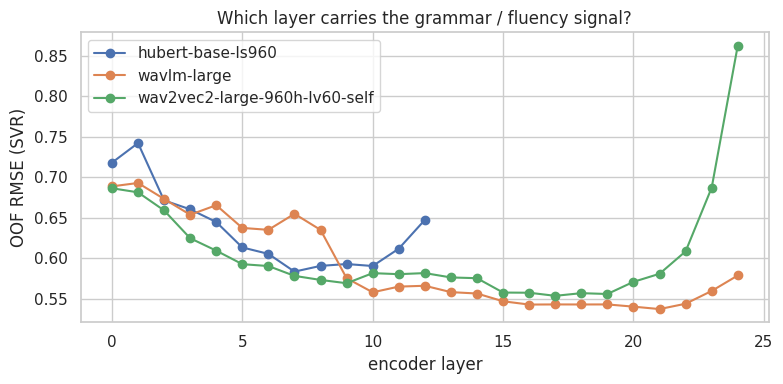

In [24]:
TOP_K = 3
new_views = {}
fig, ax = plt.subplots(figsize=(8, 4))
for bb, E in layer_embs.items():
    scores = []
    for l in range(E.shape[1]):
        X = E[:N_TR, l, :].astype(float)
        p = np.zeros(len(y))
        for tr_i, va_i in fold_sets[0]:
            p[va_i] = m_svr().fit(X[tr_i], y[tr_i]).predict(X[va_i])
        scores.append(rmse(y, np.clip(p, 0, 5)))
    best = sorted(np.argsort(scores)[:TOP_K].tolist())
    print(short(bb), "best layers:", best, "| their RMSE:", [round(scores[l], 3) for l in best])
    ax.plot(scores, marker="o", label=short(bb))
    for l in best:
        new_views[f"SVR (audio: {short(bb)} L{l})"] = (m_svr, E[:N_TR, l, :].astype(float), E[N_TR:, l, :].astype(float))
ax.set_xlabel("encoder layer"); ax.set_ylabel("OOF RMSE (SVR)"); ax.set_title("Which layer carries the grammar / fluency signal?")
ax.legend(); plt.tight_layout(); plt.show()


In [25]:
for name, (mk, Xtr, _) in new_views.items():
    reps = []
    for folds in fold_sets:
        p = np.zeros(len(y))
        for tr_i, va_i in folds:
            p[va_i] = mk().fit(Xtr[tr_i], y[tr_i]).predict(Xtr[va_i])
        reps.append(p)
    oof[name] = np.mean(reps, axis=0)
    oof_single[name] = np.mean([rmse(y, np.clip(p, 0, 5)) for p in reps])
    m = mk().fit(Xtr, y)
    train_preds[name] = m.predict(Xtr)
    test_preds[name] = m.predict(new_views[name][2])
    print(f"{name:55s} OOF RMSE = {oof_single[name]:.4f}")

names = list(views) + list(new_views)
O2 = np.column_stack([oof[n] for n in names])
stack_oof2 = np.zeros(len(y))
for tr_i, va_i in fold_sets[0]:
    stack_oof2[va_i] = LinearRegression(positive=True).fit(O2[tr_i], y[tr_i]).predict(O2[va_i])
stacker2 = LinearRegression(positive=True).fit(O2, y)

P_train2 = np.column_stack([train_preds[n] for n in names])
P_test2 = np.column_stack([test_preds[n] for n in names])
y_train_v2 = np.clip(stacker2.predict(P_train2), 0, 5)
y_test_v2 = np.clip(stacker2.predict(P_test2), 0, 5)

cv_v2 = rmse(y, np.clip(stack_oof2, 0, 5))
print("=" * 62)
print(f"v1 (7 models)  CV RMSE: {OOF_RMSE:.4f} | Pearson {OOF_PEARSON:.4f}")
print(f"v2 ({len(names)} models) CV RMSE: {cv_v2:.4f} | Pearson {pearsonr(y, np.clip(stack_oof2, 0, 5))[0]:.4f}")
print(f"v2 TRAINING RMSE: {rmse(y, y_train_v2):.4f}")
print("=" * 62)
print("top blend weights:", dict(sorted(zip(names, stacker2.coef_.round(3)), key=lambda t: -t[1])[:6]))

if cv_v2 < OOF_RMSE:
    write_sub(y_test_v2, "submission_v2.csv")
    print("v2 is better in cross-validation -> submission_v2.csv written")
else:
    print("v2 is not better in cross-validation -> keep submission.csv")


SVR (audio: hubert-base-ls960 L7)                       OOF RMSE = 0.5837
SVR (audio: hubert-base-ls960 L8)                       OOF RMSE = 0.5887
SVR (audio: hubert-base-ls960 L10)                      OOF RMSE = 0.5879
SVR (audio: wavlm-large L16)                            OOF RMSE = 0.5461
SVR (audio: wavlm-large L20)                            OOF RMSE = 0.5432
SVR (audio: wavlm-large L21)                            OOF RMSE = 0.5398
SVR (audio: wav2vec2-large-960h-lv60-self L17)          OOF RMSE = 0.5610
SVR (audio: wav2vec2-large-960h-lv60-self L18)          OOF RMSE = 0.5659
SVR (audio: wav2vec2-large-960h-lv60-self L19)          OOF RMSE = 0.5684
v1 (7 models)  CV RMSE: 0.5496 | Pearson 0.8965
v2 (16 models) CV RMSE: 0.5114 | Pearson 0.9110
v2 TRAINING RMSE: 0.2951
top blend weights: {'SVR (audio: wavlm-large L16)': np.float64(0.231), 'SVR (audio: wav2vec2-large-960h-lv60-self L17)': np.float64(0.224), 'SVR (audio: wavlm-large L20)': np.float64(0.144), 'Ridge (text: bge-larg

In [26]:
from functools import partial
 
def make_svr(C, eps, pca):
    return make_pipeline(StandardScaler(), PCA(pca, random_state=SEED), SVR(C=C, epsilon=eps, gamma="scale"))
 
def add_views(vdict):
    """cross-validate each view (all repeats), refit on all data, store predictions"""
    for name, (mk, Xtr, Xte) in vdict.items():
        reps = []
        for folds in fold_sets:
            p = np.zeros(len(y))
            for tr_i, va_i in folds:
                p[va_i] = mk().fit(Xtr[tr_i], y[tr_i]).predict(Xtr[va_i])
            reps.append(p)
        oof[name] = np.mean(reps, axis=0)
        oof_single[name] = np.mean([rmse(y, np.clip(p, 0, 5)) for p in reps])
        m = mk().fit(Xtr, y)
        train_preds[name], test_preds[name] = m.predict(Xtr), m.predict(Xte)
        print(f"{name:60s} OOF RMSE = {oof_single[name]:.4f}")
 
def restack(names):
    """non-negative linear blend of the chosen views, nested-CV evaluated"""
    O = np.column_stack([oof[n] for n in names])
    so = np.zeros(len(y))
    for tr_i, va_i in fold_sets[0]:
        so[va_i] = LinearRegression(positive=True).fit(O[tr_i], y[tr_i]).predict(O[va_i])
    st = LinearRegression(positive=True).fit(O, y)
    Ptr = np.column_stack([train_preds[n] for n in names])
    Pte = np.column_stack([test_preds[n] for n in names])
    return dict(cv_rmse=rmse(y, np.clip(so, 0, 5)), cv_pearson=pearsonr(y, np.clip(so, 0, 5))[0],
                train_rmse=rmse(y, np.clip(st.predict(Ptr), 0, 5)), test_pred=np.clip(st.predict(Pte), 0, 5))
 
svr_views = {n: v for n, v in {**views, **new_views}.items() if n.startswith("SVR")}
top_names = sorted(svr_views, key=lambda n: oof_single[n])[:5]
tuned_views = {}
for n in top_names:
    _, Xtr, Xte = svr_views[n]
    best = None
    for C in [1, 3, 10]:
        for eps in [0.05, 0.2]:
            for pca in [32, 64, 128]:
                p = np.zeros(len(y))
                for tr_i, va_i in fold_sets[0]:
                    p[va_i] = make_svr(C, eps, pca).fit(Xtr[tr_i], y[tr_i]).predict(Xtr[va_i])
                r = rmse(y, np.clip(p, 0, 5))
                if best is None or r < best[0]:
                    best = (r, C, eps, pca)
    print(f"{n}: best C={best[1]}, eps={best[2]}, pca={best[3]} -> RMSE {best[0]:.4f}")
    tuned_views[n + " [tuned]"] = (partial(make_svr, best[1], best[2], best[3]), Xtr, Xte)
add_views(tuned_views)
 
names_d = list(views) + list(new_views) + list(tuned_views)
res_d = restack(names_d)
print("=" * 62)
print(f"v2 CV RMSE {cv_v2:.4f}  ->  v3 (tuned SVRs) CV RMSE {res_d['cv_rmse']:.4f} | Pearson {res_d['cv_pearson']:.4f} | train RMSE {res_d['train_rmse']:.4f}")
print("=" * 62)

SVR (audio: wavlm-large L21): best C=10, eps=0.05, pca=128 -> RMSE 0.5175
SVR (audio: wavlm-large L20): best C=10, eps=0.05, pca=128 -> RMSE 0.5242
SVR (audio: wavlm-large L16): best C=10, eps=0.05, pca=128 -> RMSE 0.5235
SVR (audio: wav2vec2-large-960h-lv60-self L17): best C=10, eps=0.2, pca=128 -> RMSE 0.5339
SVR (audio: wav2vec2-large-960h-lv60-self L18): best C=10, eps=0.05, pca=128 -> RMSE 0.5283
SVR (audio: wavlm-large L21) [tuned]                         OOF RMSE = 0.5262
SVR (audio: wavlm-large L20) [tuned]                         OOF RMSE = 0.5276
SVR (audio: wavlm-large L16) [tuned]                         OOF RMSE = 0.5301
SVR (audio: wav2vec2-large-960h-lv60-self L17) [tuned]       OOF RMSE = 0.5409
SVR (audio: wav2vec2-large-960h-lv60-self L18) [tuned]       OOF RMSE = 0.5404
v2 CV RMSE 0.5114  ->  v3 (tuned SVRs) CV RMSE 0.4905 | Pearson 0.9184 | train RMSE 0.1039


preprocessor_config.json:   0%|          | 0.00/185k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.99k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 3.06GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/947 [00:00<?, ?it/s]

whisper encoder:   0%|          | 0/985 [00:00<?, ?it/s]

whisper encoder embeddings: (985, 25, 2048)
whisper best layers: [17, 18, 24] [0.557, 0.557, 0.544]


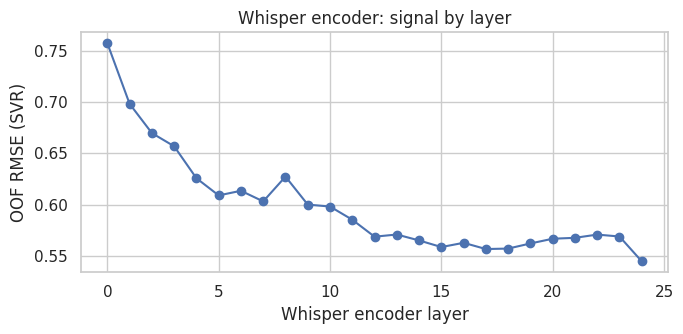

SVR (audio: whisper-medium-enc L17)                          OOF RMSE = 0.5504
SVR (audio: whisper-medium-enc L18)                          OOF RMSE = 0.5497
SVR (audio: whisper-medium-enc L24)                          OOF RMSE = 0.5470
v2 0.5114 | v3 (tuned) 0.4905 | v4 (+whisper) 0.4842   [cross-validated RMSE]
v4 Pearson 0.9206 | v4 TRAINING RMSE 0.1274
best in cross-validation: v4 -> written to submission_v3.csv


In [27]:
from transformers import WhisperFeatureExtractor, WhisperModel
WH_NAME = "openai/whisper-medium"
 
@torch.no_grad()
def whisper_layer_embeddings(name=WH_NAME):
    cp = CACHE / "layers_whisper_encoder.npy"
    if cp.exists():
        return np.load(cp)
    fe = WhisperFeatureExtractor.from_pretrained(name)
    enc = WhisperModel.from_pretrained(name, torch_dtype=torch.float16 if DEVICE == "cuda" else torch.float32).encoder.to(DEVICE).eval()
    rows = []
    for f in tqdm(all_files, desc="whisper encoder"):
        wav, _ = librosa.load(str(resolve(f)), sr=SR, mono=True)
        wav = wav[: SR * 60]
        per_chunk = []
        for i in range(0, len(wav), SR * 30):              # Whisper takes 30 s windows
            ch = wav[i:i + SR * 30]
            if len(ch) < SR:
                continue
            feats = fe(ch, sampling_rate=SR, return_tensors="pt").input_features.to(DEVICE, dtype=enc.dtype)
            hs = enc(feats, output_hidden_states=True).hidden_states
            n = max(int(len(ch) / SR * 50), 1)             # 50 encoder frames per second: ignore padding
            per_chunk.append(torch.stack([h[0, :n].float() for h in hs]))      # (layers+1, frames, hidden)
        H = torch.cat(per_chunk, dim=1)
        rows.append(torch.cat([H.mean(1), H.std(1)], dim=-1).cpu().numpy())
    arr = np.stack(rows).astype("float32")
    np.save(cp, arr)
    del enc; torch.cuda.empty_cache()
    return arr
 
WE = whisper_layer_embeddings()
print("whisper encoder embeddings:", WE.shape)
 
scores = []
for l in range(WE.shape[1]):
    X = WE[:N_TR, l, :].astype(float)
    p = np.zeros(len(y))
    for tr_i, va_i in fold_sets[0]:
        p[va_i] = m_svr().fit(X[tr_i], y[tr_i]).predict(X[va_i])
    scores.append(rmse(y, np.clip(p, 0, 5)))
best_l = sorted(np.argsort(scores)[:3].tolist())
print("whisper best layers:", best_l, [round(scores[l], 3) for l in best_l])
plt.figure(figsize=(7, 3.5)); plt.plot(scores, marker="o")
plt.xlabel("Whisper encoder layer"); plt.ylabel("OOF RMSE (SVR)"); plt.title("Whisper encoder: signal by layer"); plt.tight_layout(); plt.show()
 
whisper_views = {f"SVR (audio: whisper-medium-enc L{l})": (m_svr, WE[:N_TR, l, :].astype(float), WE[N_TR:, l, :].astype(float)) for l in best_l}
add_views(whisper_views)
 
names_e = names_d + list(whisper_views)
res_e = restack(names_e)
print("=" * 62)
print(f"v2 {cv_v2:.4f} | v3 (tuned) {res_d['cv_rmse']:.4f} | v4 (+whisper) {res_e['cv_rmse']:.4f}   [cross-validated RMSE]")
print(f"v4 Pearson {res_e['cv_pearson']:.4f} | v4 TRAINING RMSE {res_e['train_rmse']:.4f}")
print("=" * 62)
 
candidates = {"v2": (cv_v2, y_test_v2), "v3": (res_d["cv_rmse"], res_d["test_pred"]), "v4": (res_e["cv_rmse"], res_e["test_pred"])}
winner = min(candidates, key=lambda k: candidates[k][0])
write_sub(candidates[winner][1], "submission_v3.csv")
print("best in cross-validation:", winner, "-> written to submission_v3.csv")
 